fase 1) Importación de datos y selecciónizadlas de la red multiclubes que es el city group


In [1]:
import pandas as pd

# 1. Cargar los tres archivos 

df_transfers = pd.read_csv("/Users/victor personal/proyecto minería de procesos/ficheros de datos/transfers.csv")
df_clubs = pd.read_csv("/Users/victor personal/proyecto minería de procesos/ficheros de datos/clubs.csv")
df_players = pd.read_csv("/Users/victor personal/proyecto minería de procesos/ficheros de datos/players.csv")


cfg_names = [
    "Manchester City", "Girona FC", "ES Troyes AC", 
    "Palermo FC", "Lommel SK", "New York City FC", 
    "Melbourne City FC", "Montevideo City Torque"
]
cfg_clubs = df_clubs[df_clubs['name'].isin(cfg_names)]
cfg_ids = cfg_clubs['club_id'].tolist()
df_cfg_transfers = df_transfers[
    (df_transfers['from_club_id'].isin(cfg_ids)) | 
    (df_transfers['to_club_id'].isin(cfg_ids))
].copy()



# Traemos solo la posición del jugador, porque el nombre ya viene en transfers.csv
df_final = pd.merge(df_cfg_transfers, df_players[['player_id', 'position']], on='player_id', how='left')



# Traer nombre del club de origen
df_final = pd.merge(df_final, df_clubs[['club_id', 'name']], left_on='from_club_id', right_on='club_id', how='left')
df_final.rename(columns={'name': 'from_club_name'}, inplace=True)


# Traer nombre del club de destino (evitando el sufijo automático en columnas repetidas)
df_final = pd.merge(df_final, df_clubs[['club_id', 'name']], left_on='to_club_id', right_on='club_id', how='left', suffixes=('', '_drop'))
df_final.rename(columns={'name_drop': 'to_club_name', 'name': 'to_club_name_fallback'}, inplace=True)

# Seleccionar solo la primera columna en caso de que existan duplicadas accidentalmente
event_log = df_final.loc[:, ~df_final.columns.duplicated()].copy()

# Construir la tabla final asegurando nombres únicos
event_log = event_log[[
    'player_name',
    'transfer_date',
    'from_club_name',
    'to_club_name',
    'transfer_fee',
    'position'
]].copy()
event_log['Activity'] = "Movimiento a " + event_log['to_club_name'].astype(str)
event_log = event_log.sort_values(by=['player_name', 'transfer_date'])
event_log.to_csv("event_log_city_group.csv", index=False)


fase 2) descubrimiento del proceso

2.1) generar el mapa del proceso



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing






In [2]:
import pm4py
import pandas as pd

# 1. Cargar el Event Log que creaste en la Fase 1
dataframe = pd.read_csv("event_log_city_group.csv")

# 2. Formatear el DataFrame para que pm4py lo entienda
# Le decimos explícitamente cuáles son las tres columnas mágicas
dataframe = pm4py.format_dataframe(
    dataframe, 
    case_id='player_name', 
    activity_key='Activity', 
    timestamp_key='transfer_date'
)

# 3. Descubrir el modelo de proceso usando Heuristics Miner
# Este algoritmo es el que se recomienda en el curso para datos reales porque filtra el "ruido"
heu_net = pm4py.discover_heuristics_net(dataframe)

# 4. Visualizar el mapa
pm4py.view_heuristics_net(heu_net)


2.2) variantes y rendimientos ( tiempos de retención)

Se han descubierto 251 variantes (rutas distintas) en la red multiclub.

--- Las 5 rutas más repetidas son: ---
1. Ruta: ('Movimiento a Melbourne City',)
   -> Seguida por 24 jugadores.

2. Ruta: ('Movimiento a Man City',)
   -> Seguida por 22 jugadores.

3. Ruta: ('Movimiento a Girona',)
   -> Seguida por 16 jugadores.

4. Ruta: ('Movimiento a Palermo',)
   -> Seguida por 9 jugadores.

5. Ruta: ('Movimiento a Melbourne City', 'Movimiento a Without Club')
   -> Seguida por 5 jugadores.

--------------------------------------------------


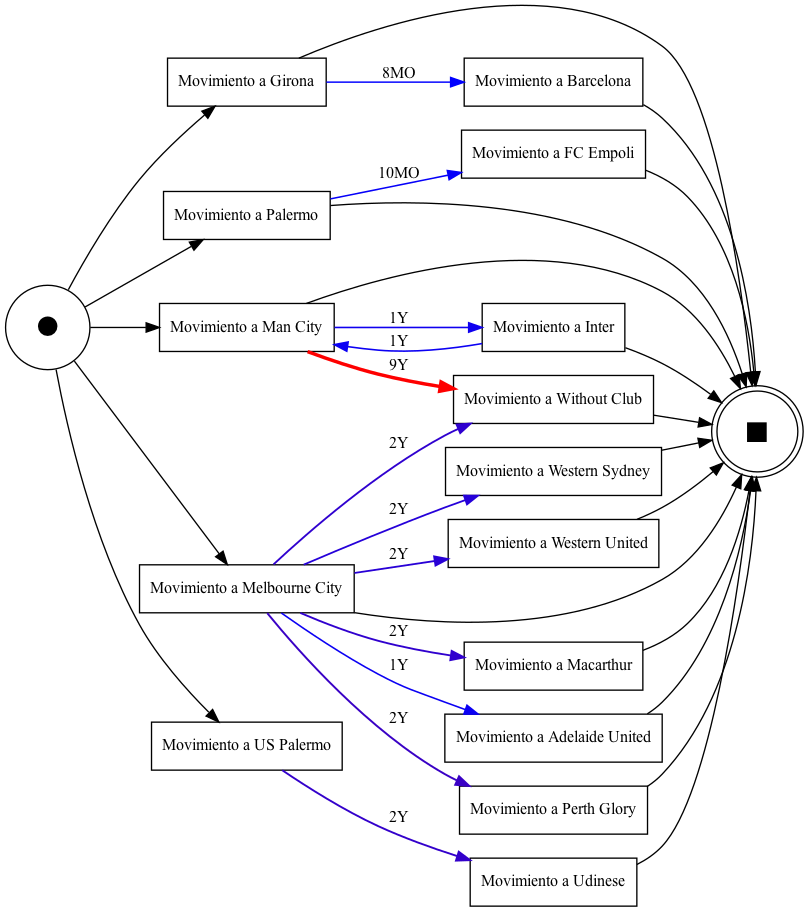

In [3]:
import pm4py


# --- A) ANÁLISIS DE VARIANTES (Rutas más comunes) ---
variants = pm4py.get_variants(dataframe)
print(f"Se han descubierto {len(variants)} variantes (rutas distintas) en la red multiclub.")
print("\n--- Las 5 rutas más repetidas son: ---")
# Como ahora el sistema ya nos da el número total contado (item[1]), ordenamos directamente por ese número
top_variants = sorted(variants.items(), key=lambda item: item[1], reverse=True)[:5]
for idx, (variant, count) in enumerate(top_variants, 1):
    print(f"{idx}. Ruta: {variant}")
    print(f"   -> Seguida por {count} jugadores.\n")
print("-" * 50)


# --- B) ANÁLISIS DE RENDIMIENTO (Tiempos de retención filtrados) ---
# 1. Filtramos los datos para quedarnos solo con el Top 15 de caminos más comunes
# Esto limpia el "ruido" de equipos raros (como el Seongnam FC) y evita que el gráfico explote
filtered_df = pm4py.filter_variants_top_k(dataframe, k=15)

# 2. Calculamos los tiempos medios en esa red ya limpia
dfg_perf, start_activities, end_activities = pm4py.discover_performance_dfg(filtered_df)

# 3. Visualizamos el mapa de rendimiento
pm4py.view_performance_dfg(dfg_perf, start_activities, end_activities)


fase 3) análisis de conformidad

In [4]:
import pandas as pd

# 1. Asegurarnos de que el ordenador entiende las fechas como fechas reales (y no como texto)
dataframe['transfer_date'] = pd.to_datetime(dataframe['transfer_date'])

# 2. Ordenar cronológicamente todo el registro por jugador
df_sorted = dataframe.sort_values(['player_name', 'transfer_date'])

# 3. Calcular la diferencia de días entre un movimiento y el siguiente del MISMO jugador
df_sorted['dias_en_el_club'] = df_sorted.groupby('player_name')['transfer_date'].diff().dt.days

# --- AUDITORÍA DE CONFORMIDAD (MODELO DE JURE) ---
# REGLA: Los movimientos secundarios no pueden darse en menos de 180 días (6 meses)
casos_ilegales = df_sorted[df_sorted['dias_en_el_club'] < 180]

# 4. Cálculo del nivel de Fitness (Conformidad general de la red)
total_movimientos_secundarios = df_sorted['dias_en_el_club'].dropna() # Movimientos que no son el primero del jugador
num_ilegales = len(casos_ilegales)
conformidad = 100 - ((num_ilegales / len(total_movimientos_secundarios)) * 100)

print(f"--- RESULTADOS DE LA AUDITORÍA DE CONFORMIDAD ---")
print(f"Nivel de Conformidad de la red City Group: {conformidad:.2f}%")
print(f"Se han detectado {num_ilegales} movimientos 'exprés' o sospechosos (menos de 6 meses de estancia).\n")

# 5. Listar a los "infractores" para analizarlos
infractores_top = casos_ilegales.sort_values('dias_en_el_club').head(5)
print("Top 5 Fichajes 'Puente' (Posible ingeniería financiera):")
for index, row in infractores_top.iterrows():
    print(f"- {row['player_name']}: {row['Activity']} a los {int(row['dias_en_el_club'])} días de su llegada.")


--- RESULTADOS DE LA AUDITORÍA DE CONFORMIDAD ---
Nivel de Conformidad de la red City Group: 54.57%
Se han detectado 333 movimientos 'exprés' o sospechosos (menos de 6 meses de estancia).

Top 5 Fichajes 'Puente' (Posible ingeniería financiera):
- Rubén Sobrino: Movimiento a Girona a los 1 días de su llegada.
- Ramón Terrats: Movimiento a Villarreal a los 1 días de su llegada.
- Issa Kaboré: Movimiento a Troyes a los 1 días de su llegada.
- Issa Kaboré: Movimiento a KV Mechelen a los 1 días de su llegada.
- Hiroshi Ibusuki: Movimiento a Sevilla Atl. a los 1 días de su llegada.


fase 4) predicción ROI ( machine learning )

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =====================================================================
# FASE 4: MODELO PREDICTIVO DE RENTABILIDAD (SVM OPTIMIZADO)
# =====================================================================

# 1. PREPARACIÓN DE LA TABLA Y FEATURE ENGINEERING
# Ajustamos las fechas para que no den error de zona horaria
dataframe['transfer_date'] = pd.to_datetime(dataframe['transfer_date']).dt.tz_localize(None)
dataframe['transfer_fee'] = dataframe['transfer_fee'].fillna(0)

# Buscamos la fecha de llegada a la red y sumamos el coste de adquisición
primer_movimiento = dataframe.groupby('player_name')['transfer_date'].min().reset_index(name='fecha_llegada')
resumen_mineria = dataframe.groupby('player_name').agg(
    num_movimientos=('Activity', 'count'),
    inversion_total=('transfer_fee', 'sum')
).reset_index()

resumen_mineria = pd.merge(resumen_mineria, primer_movimiento, on='player_name')

# Cruzamos con la base de datos de jugadores
df_players_ml = pd.read_csv("/Users/victor personal/proyecto minería de procesos/ficheros de datos/players.csv")
ml_data = pd.merge(resumen_mineria, 
                   df_players_ml[['name', 'position', 'height_in_cm', 'highest_market_value_in_eur', 'international_caps', 'international_goals', 'date_of_birth', 'foot']], 
                   left_on='player_name', right_on='name', how='inner').dropna()

# Calculamos la Edad exacta en el "Momento 0" (día de la firma)
ml_data['fecha_llegada'] = pd.to_datetime(ml_data['fecha_llegada']).dt.tz_localize(None)
ml_data['date_of_birth'] = pd.to_datetime(ml_data['date_of_birth']).dt.tz_localize(None)
ml_data['edad_al_fichar'] = (ml_data['fecha_llegada'] - ml_data['date_of_birth']).dt.days / 365.25

# 2. DEFINIR TARGET (Y) Y VARIABLES PREDICTORAS (X)
# Calculamos el ROI y establecemos el éxito en un 10% de rentabilidad
ml_data['Beneficio_Neto'] = ml_data['highest_market_value_in_eur'] - ml_data['inversion_total']
ml_data['ROI_Porcentaje'] = np.where(
    ml_data['inversion_total'] > 0, 
    (ml_data['Beneficio_Neto'] / ml_data['inversion_total']) * 100, 
    np.where(ml_data['Beneficio_Neto'] > 0, 1000.0, 0.0) 
)
ml_data['Es_Rentable'] = (ml_data['ROI_Porcentaje'] > 10.0).astype(int)

# Codificamos las variables de texto
le_pos = LabelEncoder()
le_foot = LabelEncoder()
ml_data['position_num'] = le_pos.fit_transform(ml_data['position'])
ml_data['foot_num'] = le_foot.fit_transform(ml_data['foot'])

# Nuestras variables puras de Scouting (Sin fuga de datos)
X = ml_data[['inversion_total', 'edad_al_fichar', 'international_caps', 'international_goals', 'num_movimientos', 'height_in_cm', 'position_num', 'foot_num']]
Y = ml_data['Es_Rentable']

# 3. ENTRENAMIENTO, ESCALADO Y OPTIMIZACIÓN (GRID SEARCH)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# VITAL: Escalamos los datos porque el SVM mide distancias matemáticas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Buscamos la configuración campeona del SVM
parametros_svm = {
    'C': [0.1, 1, 10, 50],             
    'kernel': ['rbf', 'linear'],       
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced']       
}

print("Iniciando Grid Search: Entrenando Máquinas de Vectores de Soporte...\n")
buscador_svm = GridSearchCV(SVC(probability=True, random_state=42), 
                            parametros_svm, cv=5, scoring='roc_auc', n_jobs=-1)
buscador_svm.fit(X_train_scaled, y_train)

# 4. AUDITORÍA Y RESULTADOS DEL MODELO CAMPEÓN
modelo_svm_perfecto = buscador_svm.best_estimator_
pred_svm = modelo_svm_perfecto.predict(X_test_scaled)

roc_auc_svm = roc_auc_score(y_test, modelo_svm_perfecto.predict_proba(X_test_scaled)[:, 1])
precision_svm = accuracy_score(y_test, pred_svm)
cm_svm = confusion_matrix(y_test, pred_svm)

print("--- RESULTADOS DEL SVM OPTIMIZADO AL MÁXIMO ---")
print(f"Mejor configuración: {buscador_svm.best_params_}")
print(f"Precisión Global: {precision_svm * 100:.2f}%")
print(f"ROC AUC Score FINAL: {roc_auc_svm:.2f}\n")

print("Matriz de Confusión (El Filtro Preventivo):")
print(f"Verdaderos Fracasos (Bloqueados): {cm_svm[0][0]} | Falsos Éxitos (Riesgo): {cm_svm[0][1]}")
print(f"Falsos Fracasos (Omitidos): {cm_svm[1][0]} | Verdaderos Éxitos (Aprobados): {cm_svm[1][1]}")


Iniciando Grid Search: Entrenando Máquinas de Vectores de Soporte...

--- RESULTADOS DEL SVM OPTIMIZADO AL MÁXIMO ---
Mejor configuración: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Precisión Global: 84.48%
ROC AUC Score FINAL: 0.91

Matriz de Confusión (El Filtro Preventivo):
Verdaderos Fracasos (Bloqueados): 13 | Falsos Éxitos (Riesgo): 0
Falsos Fracasos (Omitidos): 9 | Verdaderos Éxitos (Aprobados): 36


comparación de algoritmos a elegir

In [7]:

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 1. PREPARAMOS A LOS COMPETIDORES
# Usamos las mejores configuraciones que hemos ido descubriendo
modelos = {
    "SVM (Lineal)": SVC(kernel='linear', C=10, class_weight='balanced', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, min_samples_leaf=4, class_weight='balanced', random_state=42),
    "KNN (Vecinos)": KNeighborsClassifier(n_neighbors=7),
    "Regresión Logística": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_benchmark = []

# 2. EL COMBATE (Entrenamos y evaluamos a los 4 a la vez)
for nombre, algoritmo in modelos.items():
    # Entrenamos con los datos escalados (X_train_scaled, que ya los calculamos antes)
    algoritmo.fit(X_train_scaled, y_train)
    
    # Hacemos las predicciones
    predicciones = algoritmo.predict(X_test_scaled)
    probabilidades = algoritmo.predict_proba(X_test_scaled)[:, 1]
    
    # Calculamos métricas
    precision = accuracy_score(y_test, predicciones)
    roc_auc = roc_auc_score(y_test, probabilidades)
    cm = confusion_matrix(y_test, predicciones)
    
    # Guardamos los resultados
    resultados_benchmark.append({
        "Algoritmo": nombre,
        "ROC AUC": roc_auc,
        "Precisión (%)": precision * 100,
        "Falsos Éxitos (Errores)": cm[0][1],
        "Verdaderos Éxitos (Aciertos)": cm[1][1]
    })

# 3. LA TABLA DE CLASIFICACIÓN FINAL
tabla_resultados = pd.DataFrame(resultados_benchmark)
# Ordenamos de mejor a peor según el ROC AUC
tabla_resultados = tabla_resultados.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

print("=== COMPARADOR DEFINITIVO DE ALGORITMOS (BENCHMARK) ===\n")
print(tabla_resultados.to_string(index=False))


=== COMPARADOR DEFINITIVO DE ALGORITMOS (BENCHMARK) ===

          Algoritmo  ROC AUC  Precisión (%)  Falsos Éxitos (Errores)  Verdaderos Éxitos (Aciertos)
       SVM (Lineal) 0.914530      84.482759                        0                            36
Regresión Logística 0.907692      82.758621                        1                            36
      Random Forest 0.825641      74.137931                        3                            33
      KNN (Vecinos) 0.788889      82.758621                        6                            41
